# 00 -- Data Checks (pre-flight safety net)

Run this BEFORE `02_causal_prep` and `03_window_bucketing`.

The feature CSVs sit on a **regular hourly grid with no missing timestamps**, but ~30% of rows are **fully blank** (all sensors NaN = turbine offline). There is one **233-day** blank hole plus several 7-17 day blanks and many short ones.

This notebook:
1. Verifies index regularity + reports NaN structure
2. Detects every blank run and labels it FILL (short) or SPLIT (long)
3. Interpolates short blanks, splits the series at long blanks into continuous **segments**
4. Saves `wt{n}_clean.csv` (with a `segment_id` column, no fabricated long runs) + `segments.json` + `gap_report.csv`

**Key knob:** `SEGMENT_GAP_HOURS` -- blank runs longer than this split the data; shorter ones are interpolated.

In [21]:
import os

# -- CHANGE THESE -------------------------------------------------------------
INPUT_DIR  = r"C:\Eminds pros\E-minds projects\fuhrlander\FUHRLANDER GITHUB REPO\output"
OUTPUT_DIR = r"C:\Eminds pros\E-minds projects\fuhrlander\causal-data-engine\pipeline\clean"

SEGMENT_GAP_HOURS = 720   # blank runs > this (30 days) SPLIT into new segment; <= this are interpolated
                          #   720h keeps 2 clean segments (before/after the 233-day hole).
                          #   Lower it (e.g. 168 = 7d) to also split at the weekly/biweekly blanks.

# For the window-feasibility preview only (does not affect output):
PREVIEW_WINDOW = 10000    # rows per window  (at 5-min: 10000 rows ~ 34.7 days)
PREVIEW_STRIDE = 5000     # step between windows (at 5-min: 5000 rows ~ 17.4 days)

ROUND_DECIMALS = 6        # uniform decimal places in saved CSVs (trims long interpolation artifacts)
# -----------------------------------------------------------------------------

os.makedirs(OUTPUT_DIR, exist_ok=True)
turbine_files = {
    os.path.splitext(f)[0].replace('_features',''): os.path.join(INPUT_DIR, f)
    for f in sorted(os.listdir(INPUT_DIR)) if f.endswith('_features.csv')
} if os.path.isdir(INPUT_DIR) else {}

print('Input :', INPUT_DIR)
print('Output:', OUTPUT_DIR)
print('Files :')
for k, v in turbine_files.items():
    print('  ', k, '->', 'OK' if os.path.exists(v) else 'MISSING')

Input : C:\Eminds pros\E-minds projects\fuhrlander\FUHRLANDER GITHUB REPO\output
Output: C:\Eminds pros\E-minds projects\fuhrlander\causal-data-engine\pipeline\clean
Files :
   wt80 -> OK
   wt81 -> OK
   wt82 -> OK
   wt83 -> OK
   wt84 -> OK


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, warnings
warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 9, 'axes.grid': True, 'grid.alpha': 0.3})
print('Imports OK')

Imports OK


## 1 -- Load

In [23]:
raw = {}
for label, path in turbine_files.items():
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    df.index.name = 'timestamp'
    df = df.sort_index()
    raw[label] = df
    print(f'{label}: {len(df):,} rows x {df.shape[1]} cols  ({df.index.min()} -> {df.index.max()})')

FEATURES = list(next(iter(raw.values())).columns)
print('\nFeature columns:', FEATURES)

wt80: 308,799 rows x 11 cols  (2012-01-01 01:05:00 -> 2014-12-08 06:15:00)
wt81: 308,798 rows x 11 cols  (2012-01-01 01:10:00 -> 2014-12-08 06:15:00)
wt82: 308,799 rows x 11 cols  (2012-01-01 01:05:00 -> 2014-12-08 06:15:00)
wt83: 308,800 rows x 11 cols  (2012-01-01 01:05:00 -> 2014-12-08 06:20:00)
wt84: 308,800 rows x 11 cols  (2012-01-01 01:05:00 -> 2014-12-08 06:20:00)

Feature columns: ['wrot_avg_A_ValBl1', 'wrot_avg_V_ValBl2', 'wrot_avg_A_ValBl2', 'wrot_avg_A_ValBl3', 'wrot_avg_V_ValBl1', 'wrot_min_TmpPwrSply_ValBl1', 'wrot_min_A_ValBl1', 'wrot_max_A_ValBl2', 'wrot_sdv_TmpHtSinkPco_Bl1', 'wrot_max_V_ValBl1', 'wrot_max_TmpPwrSply_ValBl1']


## 2 -- Structural checks (index regularity, duplicates)

In [24]:
for label, df in raw.items():
    idx = df.index
    step = idx.to_series().diff().mode().iloc[0]
    dup = idx.duplicated().sum()
    mono = idx.is_monotonic_increasing
    expected = int((idx.max() - idx.min()) / step) + 1
    missing_ts = expected - len(df)
    print(f'{label}: step={step} | monotonic={mono} | duplicate_ts={dup} '
          f'| grid_missing_ts={missing_ts}')

# All turbines share the same hourly step; capture it globally
STEP = next(iter(raw.values())).index.to_series().diff().mode().iloc[0]
STEP_HOURS = STEP.total_seconds() / 3600.0
print(f'\nGlobal step: {STEP}  ({STEP_HOURS} h)')

wt80: step=0 days 00:05:00 | monotonic=True | duplicate_ts=0 | grid_missing_ts=0
wt81: step=0 days 00:05:00 | monotonic=True | duplicate_ts=0 | grid_missing_ts=0
wt82: step=0 days 00:05:00 | monotonic=True | duplicate_ts=0 | grid_missing_ts=0
wt83: step=0 days 00:05:00 | monotonic=True | duplicate_ts=0 | grid_missing_ts=0
wt84: step=0 days 00:05:00 | monotonic=True | duplicate_ts=0 | grid_missing_ts=0

Global step: 0 days 00:05:00  (0.08333333333333333 h)


## 3 -- NaN structure

Confirms blanks are **whole-row** (offline periods), not scattered.

In [25]:
rows = []
for label, df in raw.items():
    anynan = df.isna().any(axis=1)
    allnan = df.isna().all(axis=1)
    rows.append({
        'turbine': label,
        'rows': len(df),
        'rows_any_nan': int(anynan.sum()),
        'rows_all_nan': int(allnan.sum()),
        'rows_complete': int((~anynan).sum()),
        'pct_blank': round(100 * allnan.mean(), 1),
        'whole_row_blanks': bool(anynan.sum() == allnan.sum()),
    })
nan_summary = pd.DataFrame(rows).set_index('turbine')
print(nan_summary.to_string())
print('\nwhole_row_blanks=True everywhere means: a row is either fully present or fully blank.')

           rows  rows_any_nan  rows_all_nan  rows_complete  pct_blank  whole_row_blanks
turbine                                                                                
wt80     308799         93363         93363         215436       30.2              True
wt81     308798         93209         93209         215589       30.2              True
wt82     308799         95540         95540         213259       30.9              True
wt83     308800         95352         95352         213448       30.9              True
wt84     308800         98126         98126         210674       31.8              True

whole_row_blanks=True everywhere means: a row is either fully present or fully blank.


## 4 -- Blank-run detection + FILL/SPLIT verdict

In [26]:
def blank_runs(df):
    '''Return list of (start_pos, end_pos_inclusive, length) for fully-blank row runs.'''
    blank = df.isna().all(axis=1).values
    runs, i, n = [], 0, len(blank)
    while i < n:
        if blank[i]:
            j = i
            while j < n and blank[j]:
                j += 1
            runs.append((i, j - 1, j - i))
            i = j
        else:
            i += 1
    return runs

report = []
for label, df in raw.items():
    for a, b, L in blank_runs(df):
        hrs = L * STEP_HOURS
        report.append({
            'turbine': label, 'row_start': a, 'row_end': b, 'len_rows': L,
            'len_hours': round(hrs, 1), 'len_days': round(hrs / 24, 2),
            't_start': df.index[a], 't_end': df.index[b],
            'verdict': 'SPLIT' if hrs > SEGMENT_GAP_HOURS else 'FILL',
        })
gap_report = pd.DataFrame(report).sort_values(['turbine', 'row_start']).reset_index(drop=True)

print('Blank runs per turbine:')
print(gap_report.groupby('turbine')['verdict'].value_counts().to_string())
print('\nSPLIT gaps (interpolation would fabricate too much -- these break the series):')
print(gap_report[gap_report.verdict == 'SPLIT'][['turbine','t_start','t_end','len_days']].to_string(index=False))
print('\nLargest FILL gaps (these WILL be interpolated -- check you are comfortable):')
print(gap_report[gap_report.verdict == 'FILL'].nlargest(8, 'len_days')[['turbine','t_start','t_end','len_days']].to_string(index=False))

Blank runs per turbine:
turbine  verdict
wt80     FILL        75
         SPLIT        1
wt81     FILL        96
         SPLIT        1
wt82     FILL       108
         SPLIT        1
wt83     FILL        70
         SPLIT        1
wt84     FILL        77
         SPLIT        1

SPLIT gaps (interpolation would fabricate too much -- these break the series):
turbine             t_start               t_end  len_days
   wt80 2013-05-06 07:25:00 2013-12-25 05:25:00    232.92
   wt81 2013-05-06 07:25:00 2013-12-17 19:45:00    225.52
   wt82 2013-05-06 07:25:00 2013-12-25 06:20:00    232.96
   wt83 2013-05-06 07:25:00 2013-12-25 05:25:00    232.92
   wt84 2013-05-06 07:25:00 2013-12-25 06:25:00    232.96

Largest FILL gaps (these WILL be interpolated -- check you are comfortable):
turbine             t_start               t_end  len_days
   wt82 2013-02-17 22:10:00 2013-03-11 06:20:00     21.34
   wt84 2014-04-09 21:40:00 2014-04-27 06:35:00     17.38
   wt80 2013-04-15 07:25:00 2013-04-29 

## 5 -- Data-availability visualization

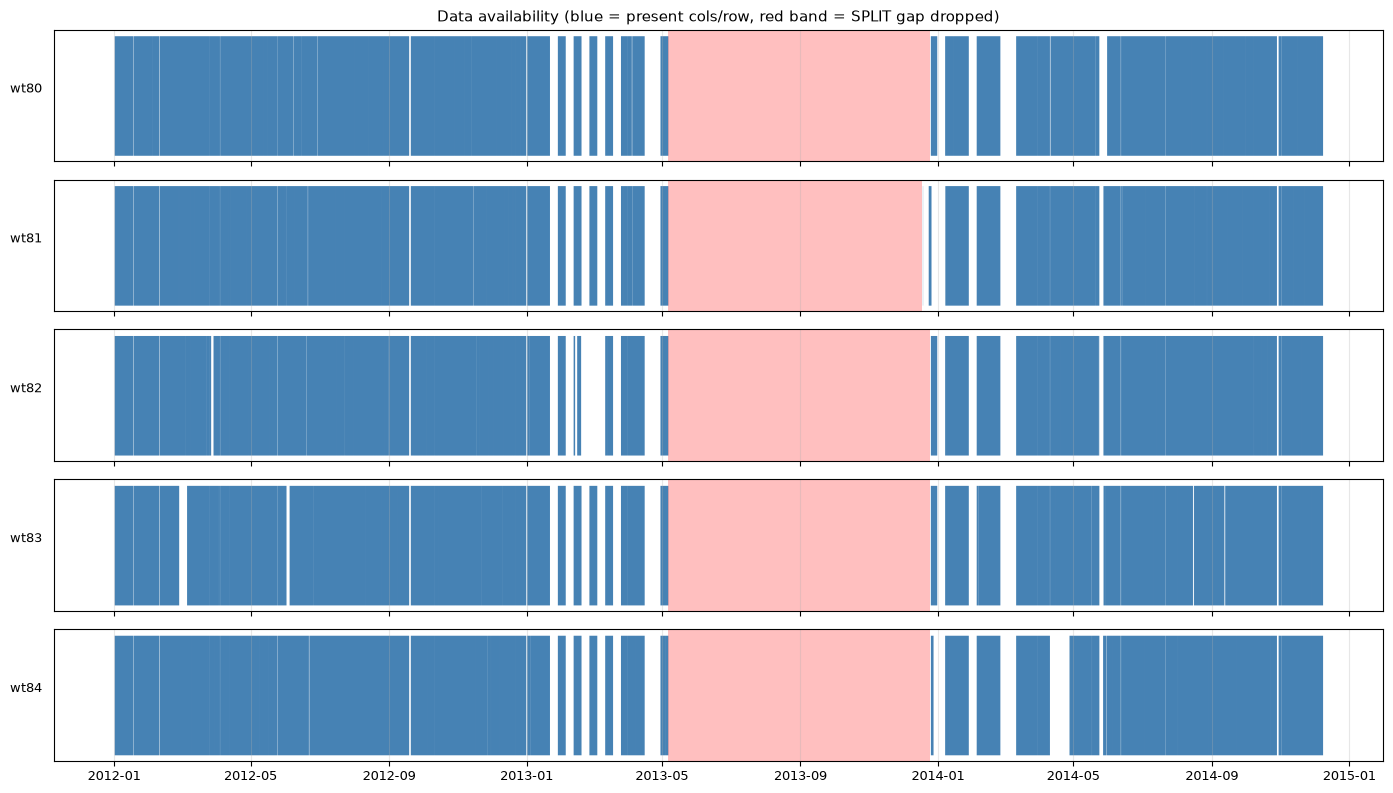

In [27]:
n = len(raw)
fig, axes = plt.subplots(n, 1, figsize=(14, 1.6 * n), sharex=True)
if n == 1: axes = [axes]
for ax, (label, df) in zip(axes, raw.items()):
    present = df.notna().sum(axis=1)            # number of non-NaN cols per row (0 = fully blank)
    ax.fill_between(df.index, 0, present, step='mid', color='steelblue', lw=0)
    # shade SPLIT gaps in red
    for _, r in gap_report[(gap_report.turbine == label) & (gap_report.verdict == 'SPLIT')].iterrows():
        ax.axvspan(r['t_start'], r['t_end'], color='red', alpha=0.25, lw=0)
    ax.set_ylabel(label, rotation=0, labelpad=20, fontsize=9)
    ax.set_yticks([])
axes[0].set_title('Data availability (blue = present cols/row, red band = SPLIT gap dropped)')
plt.tight_layout(); plt.show()

## 6 -- Build continuous segments

- Rows inside a **SPLIT** gap are dropped (no fabrication).
- A new `segment_id` starts after each SPLIT gap.
- Short (**FILL**) blanks inside a segment are time-interpolated so each segment is a complete hourly grid.

In [28]:
def build_segments(df, step_hours, split_hours):
    blank = df.isna().all(axis=1).values
    n = len(df)
    # mark rows inside a SPLIT run
    split_row = np.zeros(n, dtype=bool)
    i = 0
    while i < n:
        if blank[i]:
            j = i
            while j < n and blank[j]:
                j += 1
            if (j - i) * step_hours > split_hours:
                split_row[i:j] = True
            i = j
        else:
            i += 1
    # assign segment ids (SPLIT rows get -1 and are dropped)
    seg_id = np.full(n, -1, dtype=int)
    cur, prev_split = 0, False
    for k in range(n):
        if split_row[k]:
            prev_split = True
        else:
            if prev_split:
                cur += 1
                prev_split = False
            seg_id[k] = cur
    out = df.copy()
    out['segment_id'] = seg_id
    out = out[out['segment_id'] >= 0]
    # interpolate short blanks WITHIN each segment, drop any un-fillable edges
    feat = [c for c in out.columns if c != 'segment_id']
    parts = []
    for sid, g in out.groupby('segment_id'):
        gi = g.copy()
        gi[feat] = gi[feat].interpolate(method='time', limit_direction='both')
        gi = gi.dropna(subset=feat, how='any')
        parts.append(gi)
    return pd.concat(parts)

clean = {}
for label, df in raw.items():
    c = build_segments(df, STEP_HOURS, SEGMENT_GAP_HOURS)
    clean[label] = c
    n_seg = c['segment_id'].nunique()
    print(f'{label}: {len(df):,} raw -> {len(c):,} clean rows | {n_seg} segment(s) | NaN left: {c.drop(columns="segment_id").isna().sum().sum()}')

wt80: 308,799 raw -> 241,718 clean rows | 2 segment(s) | NaN left: 0
wt81: 308,798 raw -> 243,849 clean rows | 2 segment(s) | NaN left: 0
wt82: 308,799 raw -> 241,707 clean rows | 2 segment(s) | NaN left: 0
wt83: 308,800 raw -> 241,719 clean rows | 2 segment(s) | NaN left: 0
wt84: 308,800 raw -> 241,707 clean rows | 2 segment(s) | NaN left: 0


## 7 -- Verify segments + window feasibility preview

In [29]:
def n_windows(L, W, S):
    return 0 if L < W else (L - W) // S + 1

seg_rows = []
for label, c in clean.items():
    for sid, g in c.groupby('segment_id'):
        feat = [col for col in g.columns if col != 'segment_id']
        interp_note = ''
        seg_rows.append({
            'turbine': label, 'segment_id': sid, 'rows': len(g),
            't_start': g.index.min(), 't_end': g.index.max(),
            'span_days': round((g.index.max() - g.index.min()).total_seconds() / 86400, 1),
            f'win@{PREVIEW_WINDOW}/{PREVIEW_STRIDE}': n_windows(len(g), PREVIEW_WINDOW, PREVIEW_STRIDE),
            'win@10000/5000': n_windows(len(g), 10000, 5000),
        })
seg_table = pd.DataFrame(seg_rows)
print(seg_table.to_string(index=False))
print('\nNote the win@10000/5000 column -- Rakesh\'s original window size yields very few (or 0)')
print('windows at hourly resolution. Use smaller windows OR the 5-min data for a real evolution series.')

turbine  segment_id   rows             t_start               t_end  span_days  win@10000/5000
   wt80           0 141484 2012-01-01 01:05:00 2013-05-06 07:20:00      491.3              27
   wt80           1 100234 2013-12-25 05:30:00 2014-12-08 06:15:00      348.0              19
   wt81           0 141483 2012-01-01 01:10:00 2013-05-06 07:20:00      491.3              27
   wt81           1 102366 2013-12-17 19:50:00 2014-12-08 06:15:00      355.4              19
   wt82           0 141484 2012-01-01 01:05:00 2013-05-06 07:20:00      491.3              27
   wt82           1 100223 2013-12-25 06:25:00 2014-12-08 06:15:00      348.0              19
   wt83           0 141484 2012-01-01 01:05:00 2013-05-06 07:20:00      491.3              27
   wt83           1 100235 2013-12-25 05:30:00 2014-12-08 06:20:00      348.0              19
   wt84           0 141484 2012-01-01 01:05:00 2013-05-06 07:20:00      491.3              27
   wt84           1 100223 2013-12-25 06:30:00 2014-12-08 06

## 8 -- Save

In [30]:
# per-turbine clean CSV (with segment_id) -- uniform decimals via float_format
for label, c in clean.items():
    p = os.path.join(OUTPUT_DIR, f'{label}_clean.csv')
    c_out = c.copy()
    c_out['segment_id'] = c_out['segment_id'].astype(int)   # keep segment_id an integer
    c_out.to_csv(p, float_format=f'%.{ROUND_DECIMALS}f')    # every sensor value -> exactly ROUND_DECIMALS dp
    print('saved', p)

# gap report
gap_report.to_csv(os.path.join(OUTPUT_DIR, 'gap_report.csv'), index=False)
print('saved gap_report.csv')

# segments manifest
segments = {}
for label, c in clean.items():
    segs = []
    for sid, g in c.groupby('segment_id'):
        segs.append({'segment_id': int(sid), 'rows': int(len(g)),
                     't_start': str(g.index.min()), 't_end': str(g.index.max())})
    segments[label] = segs
with open(os.path.join(OUTPUT_DIR, 'segments.json'), 'w') as f:
    json.dump(segments, f, indent=2)
print('saved segments.json')

print('\nDone. Point 02_causal_prep and 03_window_bucketing INPUT at:', OUTPUT_DIR)

saved C:\Eminds pros\E-minds projects\fuhrlander\causal-data-engine\pipeline\clean\wt80_clean.csv
saved C:\Eminds pros\E-minds projects\fuhrlander\causal-data-engine\pipeline\clean\wt81_clean.csv
saved C:\Eminds pros\E-minds projects\fuhrlander\causal-data-engine\pipeline\clean\wt82_clean.csv
saved C:\Eminds pros\E-minds projects\fuhrlander\causal-data-engine\pipeline\clean\wt83_clean.csv
saved C:\Eminds pros\E-minds projects\fuhrlander\causal-data-engine\pipeline\clean\wt84_clean.csv
saved gap_report.csv
saved segments.json

Done. Point 02_causal_prep and 03_window_bucketing INPUT at: C:\Eminds pros\E-minds projects\fuhrlander\causal-data-engine\pipeline\clean
